In [1]:
import numpy as np
import healpy as hp
import pickle
from matplotlib.pyplot import *
import tqdm
# from cmblensplus/wrap/
import curvedsky as cs
# from cmblensplus/utils/
import cmb as CMB
import plottools as pl
import maptools
import constant as c
import binning as bn
# others
import local
import tools_multitracer as mass
import tools_delens
import tools_cmb
import warnings
warnings.filterwarnings("ignore")

In [2]:
# define parameters
lbmax  = 4*64     # maximum multipole of alm to be generated
lmax = 2*512
bN = 20
snmin = 1
snmax = 30
simn = snmax - snmin + 1
L = np.linspace(0,lbmax,lbmax+1)
lbmin, lbmax = 2, 190
mb = bn.multipole_binning(bN,lmin=lbmin,lmax=lbmax,lstart=lbmin,spc='')

In [3]:
pobj = local.analysis()

In [4]:
cobj = tools_cmb.cmb_map()
dobj = tools_delens.filename()

In [5]:
ibb = np.zeros((simn,lbmax+1))
xbb = np.zeros((simn,5,lbmax+1))
lbb = np.zeros((simn,5,lbmax+1))
for rlz in tqdm.tqdm(local.rlz(snmin,snmax),ncols=100,desc='each rlz'):
    # template B
    lblm = pickle.load(open(dobj.fLTlm['lbfull'][rlz],"rb"))
    lBlm = pickle.load(open(dobj.fLTlm['cmball'][rlz],"rb"))    
    # inpout B
    Qs, Us = hp.read_map(pobj.ficmb[rlz],field=(1,2))/c.Tcmb
    nsides = hp.get_nside(Qs)
    iblm = cs.utils.hp_map2alm_spin(nsides,lbmax,lbmax,2,Qs,Us)[1]
    # aps
    ibb[rlz-1] = cs.utils.alm2cl(lbmax,iblm)    
    for i, ctype in enumerate(dobj.ctypes):
        if ctype=='all':
            blm = lBlm[ctype][:lbmax+1,:lbmax+1]
        else:
            blm = lblm[ctype][:lbmax+1,:lbmax+1]
        xbb[rlz-1,i] = cs.utils.alm2cl(lbmax,iblm,blm)
        lbb[rlz-1,i] = cs.utils.alm2cl(lbmax,blm)

each rlz: 100%|█████████████████████████████████████████████████████| 30/30 [01:48<00:00,  3.60s/it]


In [6]:
pickle.dump( (ibb,xbb,lbb), open('../data/paper_rho_bb.pkl',"wb"), protocol=pickle.HIGHEST_PROTOCOL )

In [7]:
ibb, xbb, lbb = pickle.load(open('../data/paper_rho_bb.pkl',"rb"))

In [8]:
mxbb = bn.binning(np.mean(xbb,axis=0),mb)
mlbb = bn.binning(np.mean(lbb,axis=0),mb)
mibb = bn.binning(np.mean(ibb,axis=0),mb)

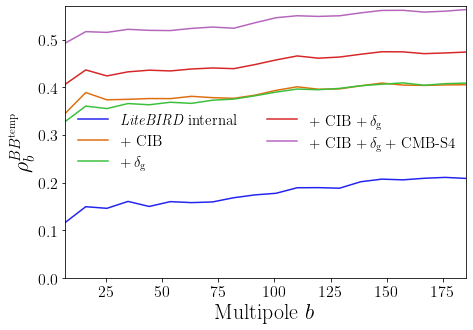

In [19]:
label = {'klb':r'{\it LiteBIRD} internal',
         'cib':r'$+$ CIB',
         'gal':r'$+\,\delta_{\rm g}$',
         'ext':r'$+$ CIB $+\,\delta_{\rm g}$',
         'all':r'$+$ CIB $+\,\delta_{\rm g}\,+$ CMB-S4'}
pl.plot_1dstyle(fsize=[7.2,5],usetex=True,xmin=mb.bc[0],xmax=mb.bc[-1],ymin=0.,ymax=.57,
                xlab=r'Multipole $b$',ylab=r'$\rho^{BB^{\rm temp}}_b$',
                xlabsize=22,ylabsize=22,
                xticks_labsize=16,yticks_labsize=16,legend_size=15)
rcParams["font.family"] = "Arial"
for i, ctype in enumerate(dobj.ctypes):
    plot(mb.bc,mxbb[i]/np.sqrt(mlbb[i]*mibb),label=label[ctype])
legend(ncol=2)
savefig('fig_rhobb.pdf',bbox_inches = 'tight', pad_inches = 0.1)